# Model Training — Happiness Score Regression

Batch ETL pipeline: clean, harmonize, engineer features, train, evaluate, and serialize.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

RAW = "../data/raw"
PROCESSED = "../data/processed"
MODELS = "../models"
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)


## Step 1 — Extract and Harmonize

In [2]:
feature_maps = {
    2015: {"happiness_score": "Happiness Score", "gdp": "Economy (GDP per Capita)",
           "family": "Family", "health": "Health (Life Expectancy)",
           "freedom": "Freedom", "generosity": "Generosity",
           "corruption": "Trust (Government Corruption)", "region": "Region"},
    2016: {"happiness_score": "Happiness Score", "gdp": "Economy (GDP per Capita)",
           "family": "Family", "health": "Health (Life Expectancy)",
           "freedom": "Freedom", "generosity": "Generosity",
           "corruption": "Trust (Government Corruption)", "region": "Region"},
    2017: {"happiness_score": "Happiness.Score", "gdp": "Economy..GDP.per.Capita.",
           "family": "Family", "health": "Health..Life.Expectancy.",
           "freedom": "Freedom", "generosity": "Generosity",
           "corruption": "Trust..Government.Corruption."},
    2018: {"happiness_score": "Score", "gdp": "GDP per capita",
           "family": "Social support", "health": "Healthy life expectancy",
           "freedom": "Freedom to make life choices", "generosity": "Generosity",
           "corruption": "Perceptions of corruption"},
    2019: {"happiness_score": "Score", "gdp": "GDP per capita",
           "family": "Social support", "health": "Healthy life expectancy",
           "freedom": "Freedom to make life choices", "generosity": "Generosity",
           "corruption": "Perceptions of corruption"},
}

frames = []
for year, mapping in feature_maps.items():
    df = pd.read_csv(f"{RAW}/{year}.csv")
    subset = df[[v for v in mapping.values() if v in df.columns]].rename(
        columns={v: k for k, v in mapping.items()}
    )
    subset["year"] = year
    country_col = "Country" if "Country" in df.columns else "Country or region"
    subset["country"] = df[country_col].values
    frames.append(subset)

df_all = pd.concat(frames, ignore_index=True)
print("Combined shape:", df_all.shape)
df_all.head()


Combined shape: (782, 10)


,happiness_score,gdp,family,health,freedom,generosity,corruption,region,year,country
0,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,Western Europe,2015,Switzerland
1,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,Western Europe,2015,Iceland
2,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,Western Europe,2015,Denmark
3,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,Western Europe,2015,Norway
4,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,North America,2015,Canada


## Step 2 — Clean and Harmonize

In [3]:
# Fill missing region with 'Unknown'
if "region" in df_all.columns:
    df_all["region"] = df_all["region"].fillna("Unknown")
else:
    df_all["region"] = "Unknown"

# Drop rows where target is missing
df_all = df_all.dropna(subset=["happiness_score"])

# Features used by the model
FEATURES = ["gdp", "family", "health", "freedom", "generosity", "corruption"]

# Fill missing feature values with the year-level median
for feat in FEATURES:
    df_all[feat] = df_all.groupby("year")[feat].transform(
        lambda x: x.fillna(x.median())
    )

# Final drop of any remaining NaN rows
df_all = df_all.dropna(subset=FEATURES)
df_all = df_all.reset_index(drop=True)

print("Clean shape:", df_all.shape)
print("Null counts:\n", df_all[FEATURES + ['happiness_score']].isnull().sum())
df_all.describe()


Clean shape: (782, 10)
Null counts:
 gdp                0
family             0
health             0
freedom            0
generosity         0
corruption         0
happiness_score    0
dtype: int64


,happiness_score,gdp,family,health,freedom,generosity,corruption,year
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,5.379018,0.916047,1.078392,0.612416,0.411091,0.218576,0.125380,2016.993606
std,1.127456,0.407340,0.329548,0.248309,0.152880,0.122321,0.105760,1.417364
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000
25%,4.509750,0.606500,0.869363,0.440183,0.309768,0.130000,0.054250,2016.000000
50%,5.322000,0.982205,1.124735,0.647310,0.431000,0.201982,0.090905,2017.000000
75%,6.189500,1.236187,1.327250,0.808000,0.531000,0.278832,0.155861,2018.000000
max,7.769000,2.096000,1.644000,1.141000,0.724000,0.838075,0.551910,2019.000000


## Step 3 — Feature Engineering

Correlation with happiness_score:
 happiness_score     1.000000
positive_factors    0.815058
gdp                 0.789284
social_wellbeing    0.774966
health              0.742456
family              0.648799
freedom             0.551258
corruption          0.397333
generosity          0.137578
Name: happiness_score, dtype: float64


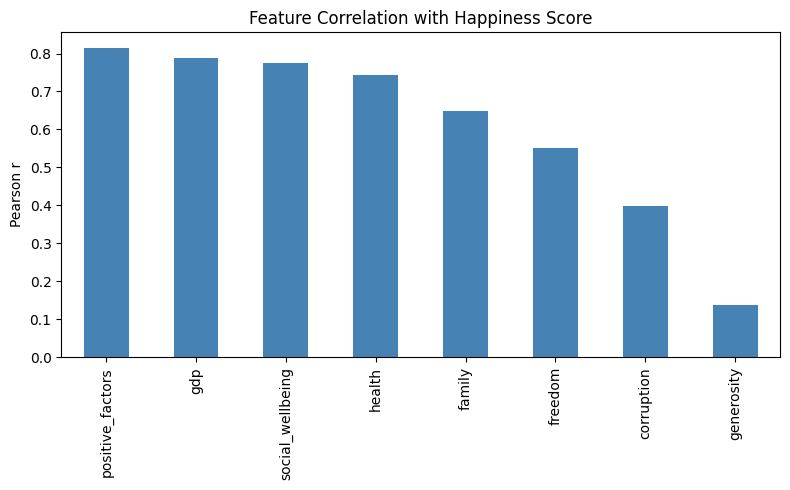

In [4]:
# Feature: social_wellbeing (combined family + health)
df_all["social_wellbeing"] = df_all["family"] + df_all["health"]

# Feature: positive_factors (gdp + freedom + generosity - corruption)
df_all["positive_factors"] = df_all["gdp"] + df_all["freedom"] + df_all["generosity"] - df_all["corruption"]

FEATURES_ENG = FEATURES + ["social_wellbeing", "positive_factors"]

# Correlation with target
corr = df_all[FEATURES_ENG + ["happiness_score"]].corr()["happiness_score"].sort_values(ascending=False)
print("Correlation with happiness_score:\n", corr)

plt.figure(figsize=(8, 5))
corr.drop("happiness_score").plot(kind="bar", color="steelblue")
plt.title("Feature Correlation with Happiness Score")
plt.ylabel("Pearson r")
plt.tight_layout()
plt.savefig(f"{PROCESSED}/feature_correlation.png", dpi=100, bbox_inches='tight')
plt.show()


In [5]:
# Save unified processed dataset
df_all.to_csv(f"{PROCESSED}/happiness_unified.csv", index=False)
print("Saved:", f"{PROCESSED}/happiness_unified.csv")


Saved: ../data/processed/happiness_unified.csv


## Step 4 — Train/Test Split & Model Training

In [6]:
X = df_all[FEATURES_ENG]
y = df_all["happiness_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


Train: 547 rows | Test: 235 rows


In [7]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    print(f"{name:30s} | MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return model, preds

models = {
    "Linear Regression":       LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42),
}

results = {}
for name, m in models.items():
    trained_model, preds = evaluate(name, m, X_train, X_test, y_train, y_test)
    results[name] = (trained_model, preds)


Linear Regression              | MAE=0.4486  RMSE=0.5843  R²=0.7266


Random Forest Regressor        | MAE=0.4045  RMSE=0.5185  R²=0.7847
Decision Tree Regressor        | MAE=0.5050  RMSE=0.6543  R²=0.6571


## Step 5 — Select Best Model and Serialize

In [8]:
# Use Linear Regression as per workshop instructions (focus on pipeline, not accuracy)
best_model = results["Linear Regression"][0]
best_preds = results["Linear Regression"][1]

model_path = f"{MODELS}/model.pkl"
joblib.dump(best_model, model_path)
print(f"Model saved: {model_path}")

# Save feature list alongside model for consistent inference
feature_meta = {"features": FEATURES_ENG}
joblib.dump(feature_meta, f"{MODELS}/feature_meta.pkl")
print("Feature metadata saved.")


Model saved: ../models/model.pkl
Feature metadata saved.


## Step 6 — Evaluation Visualizations

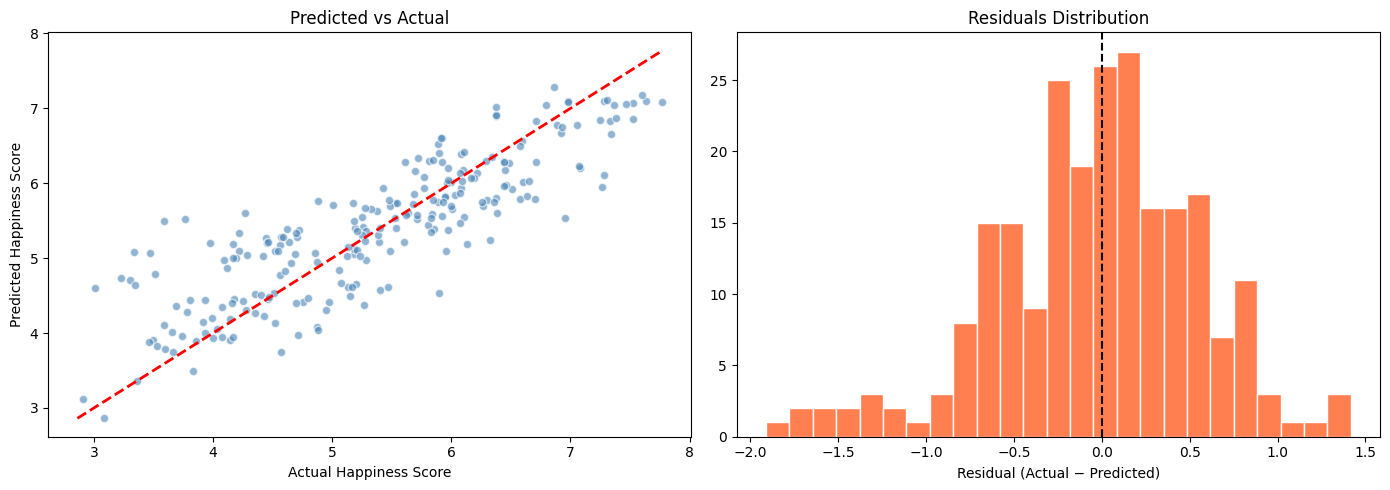


Final Model — Linear Regression
  MAE  = 0.4486
  RMSE = 0.5843
  R²   = 0.7266


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, best_preds, alpha=0.6, color='steelblue', edgecolors='white')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel("Actual Happiness Score")
axes[0].set_ylabel("Predicted Happiness Score")
axes[0].set_title("Predicted vs Actual")

# Residuals
residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=25, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_title("Residuals Distribution")

plt.tight_layout()
plt.savefig(f"{PROCESSED}/model_evaluation.png", dpi=100, bbox_inches='tight')
plt.show()

mae  = mean_absolute_error(y_test, best_preds)
rmse = np.sqrt(mean_squared_error(y_test, best_preds))
r2   = r2_score(y_test, best_preds)
print(f"\nFinal Model — Linear Regression")
print(f"  MAE  = {mae:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  R²   = {r2:.4f}")
